### APRENDIZAJE PROFUNDO CON TENSORFLOW Y REDES NEURONALES CONVOLUCIONALES

### 1. Desarrollar el código en un Notebook de Jupyter Lab.

#### Entrenar una Red Neuronal para que reconozca imágenes de animales

### Solo perro, gato, caballo y ciervo

### Importamos las bibliotecas necesarias

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
from tkinter import filedialog
from tkinter import Tk
from PIL import Image
import cv2


In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

#### Las clases a filtrar (3: gato, 5: perro, 7: caballo, 4: ciervo)

In [3]:
animal_classes = [3, 5, 7, 4]
animal_class_names = ['gato', 'perro', 'caballo', 'ciervo']

#### Filtrar los datos de entrenamiento

In [4]:
train_filter = np.isin(train_labels, animal_classes).reshape(-1)
train_images_filtered = train_images[train_filter]
train_labels_filtered = train_labels[train_filter]

#### Filtrar los datos de prueba

In [5]:
test_filter = np.isin(test_labels, animal_classes).reshape(-1)
test_images_filtered = test_images[test_filter]
test_labels_filtered = test_labels[test_filter]

#### Reetiquetar las clases (de 3,5,7,4 a 0,1,2,3)

In [6]:
for i, class_num in enumerate(animal_classes):
    train_labels_filtered[train_labels_filtered == class_num] = i
    test_labels_filtered[test_labels_filtered == class_num] = i

#### Normalizar los datos

In [7]:
train_images_filtered, test_images_filtered = train_images_filtered / 255.0, test_images_filtered / 255.0

#### Mostrar ejemplos del dataset filtrado

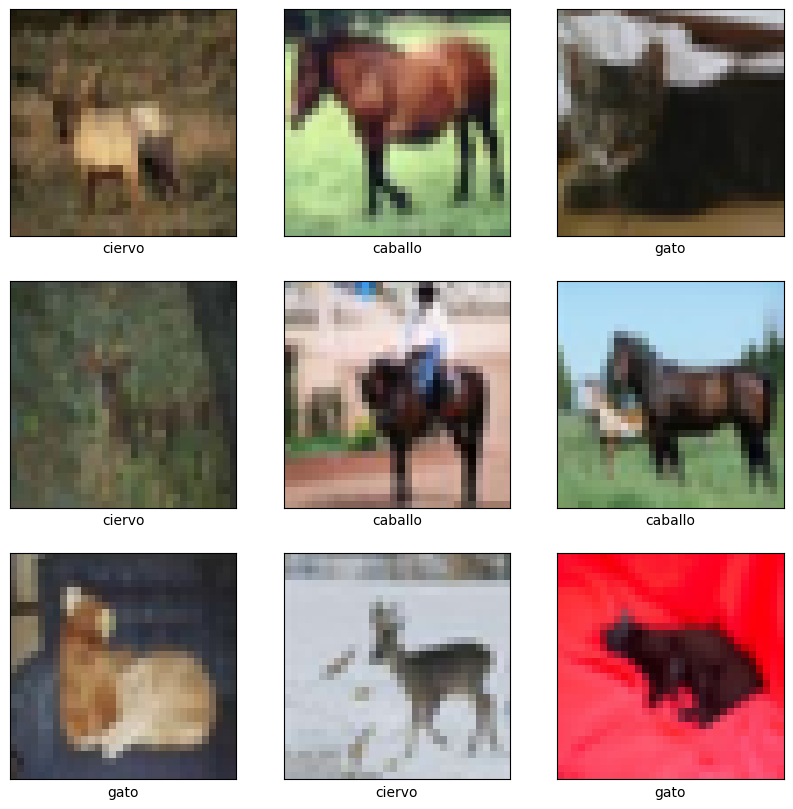

In [8]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images_filtered[i])
    plt.xlabel(animal_class_names[train_labels_filtered[i][0]])
plt.show()

#### Construir el modelo de red neuronal convolucional

In [9]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(4)  # 4 clases (gato, perro, caballo, ciervo)
])

c:\Users\Estudiante\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Compilar el modelo

In [10]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

#### Entrenar el modelo


In [21]:
history = model.fit(train_images_filtered, train_labels_filtered, epochs=100,
                    validation_data=(test_images_filtered, test_labels_filtered))

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9578 - loss: 0.1151 - val_accuracy: 0.7050 - val_loss: 1.4283
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9592 - loss: 0.1093 - val_accuracy: 0.7082 - val_loss: 1.4277
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9589 - loss: 0.1105 - val_accuracy: 0.7092 - val_loss: 1.5106
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9719 - loss: 0.0816 - val_accuracy: 0.6975 - val_loss: 1.7545
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9614 - loss: 0.1030 - val_accuracy: 0.7038 - val_loss: 1.5483
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9696 - loss: 0.0819 - val_accuracy: 0.6970 - val_loss: 1.7243
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9757 - loss: 0.0686 - val_accuracy: 0.7070 - val_loss: 1.7618
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9752 - loss: 0.0732 - val_accu

#### Visualizamos la historia de aprendizaje

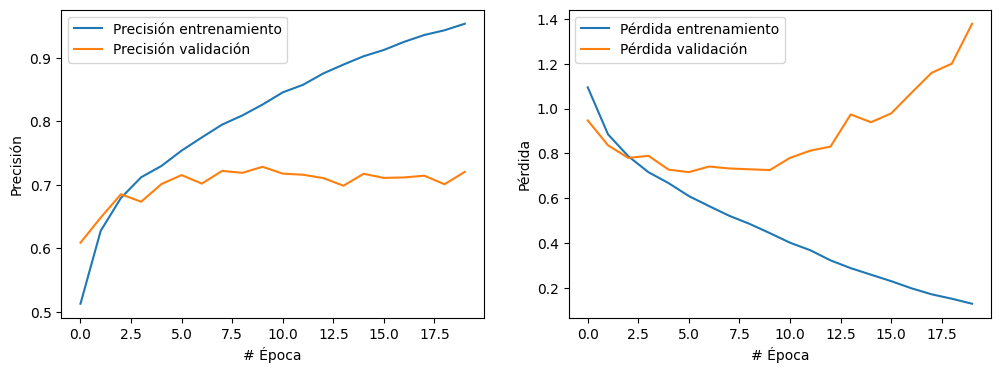

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Precisión entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión validación')
plt.xlabel('# Época')
plt.ylabel('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida validación')
plt.xlabel('# Época')
plt.ylabel('Pérdida')
plt.legend()

plt.show()

#### Evaluar el modelo

In [13]:
test_loss, test_acc = model.evaluate(test_images_filtered, test_labels_filtered, verbose=2)
print(f'Precisión en el conjunto de prueba: {test_acc}')

125/125 - 0s - 2ms/step - accuracy: 0.7205 - loss: 1.3785
Precisión en el conjunto de prueba: 0.7204999923706055


#### Preparamos una imagen de prueba

In [14]:
def preparar_imagen(img):
    img = np.expand_dims(img, axis=0)  # Añadir una dimensión para que sea compatible con el modelo
    return img

#### Seleccionar una imagen del dataset de prueba

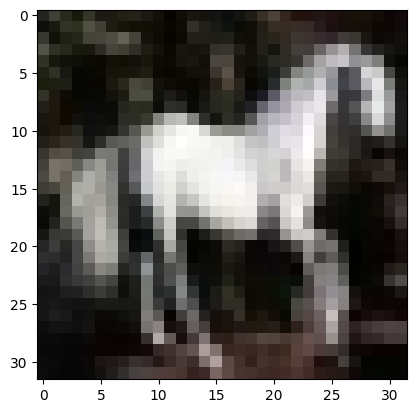

In [15]:
test_image = test_images_filtered[3]
plt.imshow(test_image)
plt.show()

#### Predicción

In [16]:
predictions = model.predict(preparar_imagen(test_image))
predicted_class = np.argmax(predictions)

print(f"La imagen mostrada es: {animal_class_names[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
La imagen mostrada es: caballo


#### Función para preparar imágenes externas

In [17]:
def prepare_image(img):
    img = cv2.resize(img, (32, 32))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return img

#### Interfaz visual para cargar imágenes desde el entorno local

In [18]:
def upload_and_predict():
    root = Tk()
    root.withdraw()  # Ocultar la ventana principal
    file_path = filedialog.askopenfilename()  # Abrir un diálogo para seleccionar archivo
    img = Image.open(file_path)
    img = np.array(img)

    plt.imshow(img)
    plt.title("imagen cargada")
    plt.show()

    prepared_image = prepare_image(img)
    prediction = model.predict(prepared_image)
    predicted_class = np.argmax(prediction)

    print(f"El animal en la imagen es: {animal_class_names[predicted_class]}")

#### Llamamos a la función de carga y predicción

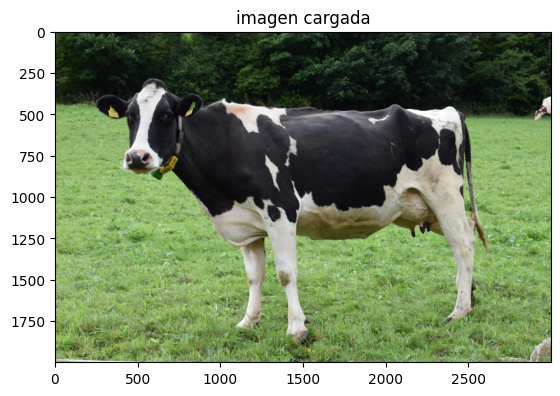

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
El animal en la imagen es: caballo


In [20]:
upload_and_predict()